<center>Final Project: Data Science Pipeline Tutorial<\center>
<center>Alcohol's Effect on Academic Performance<\center>
<center>Benjamin Yi, Arno Babcock, and Petr Tsypnyatov<\center>

For our final project, we decided to focus on data containing key information on student alcohol consumption, which we found on data.world. In this tutorial, we will be showing you the various steps of the Data Science Pipeline, and how you can analyze and use whatever data you might be interested in. These steps can be broken down into the following:
Data collection/curation + parsing (if necessary),
Data management/representation,
Exploratory data analysis,
Hypothesis testing and machine learning, and
Communication of insights attained.
<br>
There are a few things that we will need to do to get set up. <br>
1. You will need an IDE to be able to run and test your code. We will be using Jupyter Notebook for this project, and recommend you do the same as it also functions as a presentation tool.<br>
2. Once you have an IDE installed, you can create a new file and begin writing your code.<br>
3. For this particular project, we are going to use a few Python libraries, which we will have listed here.<br>
-pandas<br>
-numpy<br>
-matplotlib.pyplot<br>
-sklearn<br>
4. Once you have all this set up, we can begin with the first step: collecting and parsing the data.<br>

# Data collection/curation + parsing (if necessary)

The first step of the Data Science Pipeline is finding the data you want to analyze. In our case, we want to take a look at the statistics for student alcohol consumption, and we are given a dataset as a .csv file. There are many ways for you to collect, or "scrape" your data, it can be on a website, in a table, or as an excel file. Since our data is in the form of a .csv file, we will use the pandas library to read it. We can use the read_csv() method from the pandas library to create a DataFrame object from a .csv file. A dataframe is a 2-dimensional labeled structure with columns that can have different types, which is perfect for what we need. We create the DataFrame, and assign it to a variable table, and then display table.

Note: What goes in parentheses is actually the path to the file that we want to read data from. Since we have the .csv file in the same folder as this project, we can just write the filename, otherwise you would need to add the entire file path before the name of the file.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv("student-mat.csv")
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10


Now that we have the data as a DataFrame object, we can begin the next step which is managing and representing our data.

# Data management/representation

When we take a look at our data, there are a lot of columns containing variables that we are not really interested in. Some of the variables that we will not need include school, address, reason, guardian, travel time, schoolsup, famsup, paid, activity, nursery, higher, internet, and romantic. The pandas library provides us with some easy methods to use to drop these columns from the dataframe. 

In [38]:
data = data.drop(['school', 'address', 'reason', 'guardian', 'traveltime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic'], axis=1)
data

,sex,age,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,F,18,GT3,A,4,4,at_home,teacher,2,0,4,3,4,1,1,3,6,5,6,6
1,F,17,GT3,T,1,1,at_home,other,2,0,5,3,3,1,1,3,4,5,5,6
2,F,15,LE3,T,1,1,at_home,other,2,3,4,3,2,2,3,3,10,7,8,10
3,F,15,GT3,T,4,2,health,services,3,0,3,2,2,1,1,5,2,15,14,15
4,F,16,GT3,T,3,3,other,other,2,0,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,LE3,A,2,2,services,services,2,2,5,5,4,4,5,4,11,9,9,9
391,M,17,LE3,T,3,1,services,services,1,0,2,4,5,3,4,2,3,14,16,16
392,M,21,GT3,T,1,1,other,other,1,3,5,5,3,3,3,3,3,10,8,7
393,M,18,LE3,T,3,2,services,other,1,0,4,4,1,3,4,5,0,11,12,10


Now we have a much tidier dataset to look at. We can further simplify the DataFrame by looking at the grade columns G1, G2, and G3. These refer to the grades a student received in the first semester, second semester, and their final grade. For the purpose of our project, we can add these scores up and instead of having 3 separate columns, we can create one column to hold each student's grade score. We can do the same thing for drinking and add the Dalc, which represents how much a student drinks during the week, and Walc, which represents how much a student drinks during the weekend.

In [39]:
data['grade_score'] = data['G1'] + data['G2'] + data['G3']
data = data.drop(['G1', 'G2', 'G3'], axis = 1)
data['drink_score'] = data['Dalc'] + data['Walc']
data

,sex,age,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,grade_score,drink_score
0,F,18,GT3,A,4,4,at_home,teacher,2,0,4,3,4,1,1,3,6,17,2
1,F,17,GT3,T,1,1,at_home,other,2,0,5,3,3,1,1,3,4,16,2
2,F,15,LE3,T,1,1,at_home,other,2,3,4,3,2,2,3,3,10,25,5
3,F,15,GT3,T,4,2,health,services,3,0,3,2,2,1,1,5,2,44,2
4,F,16,GT3,T,3,3,other,other,2,0,4,3,2,1,2,5,4,26,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,LE3,A,2,2,services,services,2,2,5,5,4,4,5,4,11,27,9
391,M,17,LE3,T,3,1,services,services,1,0,2,4,5,3,4,2,3,46,7
392,M,21,GT3,T,1,1,other,other,1,3,5,5,3,3,3,3,3,25,6
393,M,18,LE3,T,3,2,services,other,1,0,4,4,1,3,4,5,0,33,7


Now that is our data is in the form that we want it, we can start to analyze these numbers to come to a conclusion.

# Exploratory data analysis

Using the matplotlib library we can plot our data in the form of graphs which we can use to do all kinds of things, like detect trends in our data. The first thing that we can do is a simple bar graph, where we compare boy's alcohol consumption to girl's. 

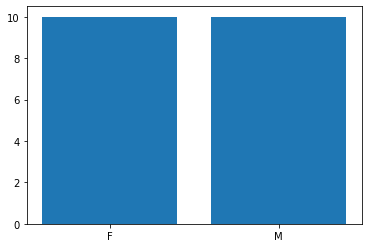

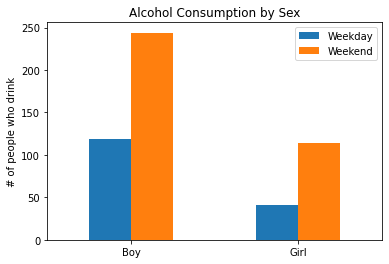

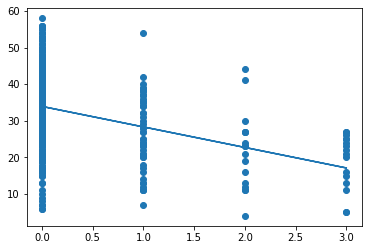

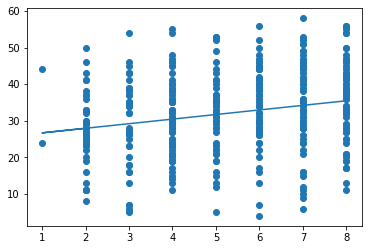

In [41]:
female_drinks = 0
male_drinks = 0

for index, row in data.iterrows():
    if row['Walc'] >= 2 and row['sex'] == "F":
        female_drinks += 1
    if row['Walc'] >= 2 and row['sex'] == "M":
        male_drinks += 1

plt.bar(data['sex'], data['drink_score'])
plt.show()







d_alcB= 0
w_alcB = 0

d_alcF = 0
w_alcF = 0

cur_D = 0
cur_W = 0;

for t in data.groupby("sex"):
    for index, row in t[1].iterrows():
        if row['Walc'] >= 2:
            cur_W+=1
        if row['Dalc'] >= 2:
            cur_D+=1

    if t[0] == "F":
        w_alcF = cur_W
        d_alcF = cur_D
    else:
        w_alcB = cur_W
        d_alcB = cur_D


d_alc = [d_alcB, d_alcF]
w_alc = [w_alcB, w_alcF]
index = ['Boy','Girl']

df = pd.DataFrame({'Weekday': d_alc,'Weekend': w_alc}, index=index)
ax = df.plot.bar(rot=0)
plt.ylabel("# of people who drink")
plt.title("Alcohol Consumption by Sex")
plt.show()






m, b = np.polyfit(data['failures'],data['grade_score'], 1)
plt.plot(data['failures'],m*data['failures'] + b)
plt.scatter(x=data['failures'],y=data['grade_score'])


plt.show()
data['parent_edu'] = 0;

for index, row in data.iterrows():
    data.at[index,'parent_edu'] = row['Medu']+ row['Fedu']


m, b = np.polyfit(data['parent_edu'],data['grade_score'], 1)
plt.plot(data['parent_edu'],m*data['parent_edu'] + b)
plt.scatter(x=data['parent_edu'],y=data['grade_score'])


plt.show()

In [33]:
# Hypothesis testing and machine learning
# Communication of insights attained